In [1]:
import numpy as np
from scipy.integrate import solve_ivp, quad, cumulative_trapezoid
from scipy.constants import G
from matplotlib import pyplot as plt
from matplotlib.scale import LogScale
from numba import jit
import time
from joblib import Parallel, delayed
import warnings

In [2]:
# Constants
Omega_r0 = 9.89e-5
Omega_m0 = 0.3
Omega_m0_h_squared = 0.1424
Omega_b0_h_squared = 0.02242
Omega_phi0 = 1-Omega_r0-Omega_m0
Omega_b0 = 0.05
h = 0.65
w_r = 1/3
z_dec = 1089
theta_star_obs = 1.04109e-2

In [3]:
def rho_r(a):
    return 3*Omega_r0*a**(-4)

def rho_m(a):
    return 3*Omega_m0*a**(-3)

In [4]:
# Step function way
def calculate_w_phi_square(z, zmin=8, zmax=25, wmax = 1):
    if zmin<z<zmax:
        return wmax
    else:
        return -1.5


# Cool guy way
def calculate_w_phi(z, zmin, zmax, wmax = 1, width=0.8):
    
    # Smooth step up at z=23 (from -1 to 1)
    step_up = 0.5 * (1 - np.tanh((z - zmax) / (3*width)))
    
    # Smooth step down at z=5 (from 1 to -1)  
    step_down = 0.5 * (1 - np.tanh((zmin - z) / width))
    
    # Combine: -1 outside, +1 inside [5,25]
    w = -1 + 2 * step_up * step_down
    
    return w

z_test = 30
zmin_test = 5
zmax_test = 23
print(f"If z is {z_test} then w_phi is: {calculate_w_phi(z_test, zmin_test, zmax_test)}.")

If z is 30 then w_phi is: -0.9941605004152156.


In [5]:
def ode_system(eta, state, w_phi_function, Omega_m0, Omega_b0):
    """
    System of ODEs in conformal time eta
    """
    rho_phi, H, a, t, hs = state
    
    z_current = (1/a)-1
    rho_r_current = rho_r(a)
    
    """
    Needed to calculated hs
    """
    R = (30230*Omega_b0_h_squared)/(1+z_current)
    cs = 1/(np.sqrt(3*(1+R)))
    
    """
    Dark Energy Potential function
    """
    w_phi = w_phi_function(z_current)
    
    """
    ODEs
    """
    drho_phi_deta = -3*a*H*(1+w_phi)*rho_phi
    dH_deta = -(3/2)*a*H**2-(a/2)*(w_r * rho_r_current+w_phi*rho_phi)
    da_deta = a**2*H
    dt_deta = a
    dhs_deta = cs
    
    
    return [drho_phi_deta, dH_deta, da_deta, dt_deta, dhs_deta]

In [6]:
def solve_single_case(w_phi_function, omega_m0 = 0.3, omega_b0 =  0.05, H0=65, initial_state = [3*Omega_phi0, 1.0, 1.0, 0.96, 0], graph = False):
    
    warnings.filterwarnings('ignore', category=RuntimeWarning)
    wphi = w_phi_function
    
    solution = solve_ivp(
                        ode_system,
                        eta_span,
                        initial_state,
                        t_eval = eta_eval,
                        method = 'DOP853',
                        args = (wphi, omega_m0, omega_b0),
                        rtol = 1e-9,
                        atol = 1e-11
                    )
    
    output_data = calculate_observables(solution, wphi, H0, graph)
    
    if graph == True:
        return output_data
    
    else:
        wavg = output_data[14]
        theta = output_data[16]
        delta_theta = output_data[17]
        del solution
        return wavg, theta, delta_theta


def case_wrapper(H0, sww, zMax, maxw):
    wave_width = zMax * sww
    zMin = zMax - wave_width

    h = H0/100

    Omega_m0 = Omega_m0_h_squared / h**2
    Omega_b0 = Omega_b0_h_squared / h**2
    Omega_phi_0 = 1 - Omega_m0 - Omega_r0

    ICs = [3*Omega_phi_0, 1.0, 1.0, 0.96, 0]
    
    wphi = lambda z: calculate_w_phi_square(z, zMin, zMax, maxw)
    return solve_single_case(wphi, Omega_m0, Omega_b0, H0, ICs)

In [ ]:
def calculate_z_vals(aValues):
    z_vals = 1/aValues - 1
    opz_vals = 1/aValues
    return z_vals, opz_vals

def calculate_density_parameters(rhoPhiValues, rhoMValues, rhoRValues, hValues):
    omega_phis = rhoPhiValues/(3*hValues**2)
    omega_ms = rhoMValues/(3*hValues**2)
    omega_rs = rhoRValues/(3*hValues**2)
    return omega_phis, omega_ms, omega_rs

def calculate_q(omegaR, omegaM, wPhi, omegaPhi):
    return omegaR + (1/2) * omegaM + (1/2) * (1 + 3 * wPhi) * omegaPhi

def calculate_dtheta_deta(aValues, wPhi, rhoPhi):
    return aValues * np.sqrt((1 + wPhi) * rhoPhi)

def calculate_w_phi_average(omegaPhi, wPhi, space, idxDec):
    numerator = cumulative_trapezoid(omegaPhi[::-1] * wPhi[::-1], space, initial = 0)
    denominator = cumulative_trapezoid(omegaPhi[::-1], space, initial=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        wphiavg =  numerator / denominator
    return wphiavg[::-1]

def calculate_zDec(zValues):
    idxDec = np.argmin(np.abs(zValues-z_dec)) #Index of z_dec
    return idxDec

def calculate_parameter_Dec(index, parameter):
    return parameter[index]

@jit(nopython=True)
def eta_integral_function(a, omega_phi0, omega_m0, wphi_average):
    """To pass to the eta0 integral below"""
    term1 = a
    term2 = (omega_phi0/omega_m0) * a**(1-3*(wphi_average))
    term3 =  Omega_r0/omega_m0
    return (term1 + term2 + term3)**(-1/2)
    
def calculate_eta_Zero(H0_value, omega_phi0, omega_m0, wphi_average):
    """
    Used to estimate current conformal time
    """
    #h = H0_value/100
    integral_result = quad(eta_integral_function, 0, 1, 
                          args=(omega_phi0, omega_m0, wphi_average))[0]
    
    #eta_0 = (1/(H0_value/100 * np.sqrt(omega_m0))) * integral_result
    eta_0 = (1/(np.sqrt(omega_m0))) * integral_result
    print(f"Eta 0 calculation: {eta_0}")
    
    return eta_0
    
def calculate_eta_Dec(a_dec, omega_phi_dec, omega_m0):
    term1 = (2 * np.sqrt(1 - omega_phi_dec))/(np.sqrt(omega_m0)) 
    term2 = (np.sqrt(a_dec + (Omega_r0)/(omega_m0)) - np.sqrt(Omega_r0/omega_m0))
    
    eta_Dec =  term1 * term2 
    
    """
    print(f"Eta dec calculation: {eta_Dec}")
    print(f"Eta dec theoretical: {0.063}")
    """
    return eta_Dec


def calculate_lA(rs, eta_zero, eta_dec):

    # DEBUG
    """
    print(f"  hsValues[idx_zdec] = {hsValues[index]:.6e}")
    print(f"  hsValues[-1] = {hsValues[-1]:.6e}")
    print(f"  hs_dec = {hs_dec:.6e}")    
    print(f"rs calculation: {rs}")
    print(f"  Expected r_s ≈ 0.033")  
    """
    
    return np.pi * (eta_zero - eta_dec)/rs

def calculate_theta(lA):
    return np.pi/lA

def calculate_delta_theta(theta):
    return np.abs((theta - theta_star_obs)/theta_star_obs)

In [17]:
def calculate_observables(odeSolution, w_phi_func, H0, graph):
    # Unpack
    rho_phi_values = odeSolution.y[0]
    H_values = odeSolution.y[1]
    a_values = odeSolution.y[2]
    t_values = odeSolution.y[3]
    hs_values = odeSolution.y[4]

    z_values, oneplusz_values = calculate_z_vals(a_values)
    w_phi_values = np.array([w_phi_func(z) for z in z_values])

    # Densities
    Omega_phi, Omega_m, Omega_r = calculate_density_parameters(rho_phi_values, 
                                                               rho_m(a_values), 
                                                               rho_r(a_values),
                                                               H_values)
    omega_phi0_current = Omega_phi[0]
    omega_m0_current = Omega_m[0]
    
    # Derived Quantities
    q = calculate_q(Omega_r, Omega_m, w_phi_values, Omega_phi)
    dtheta_deta = calculate_dtheta_deta(a_values, w_phi_values, rho_phi_values)
    
    # Decoupling
    idx_zdec = calculate_zDec(z_values)
    omegaphidec = calculate_parameter_Dec(idx_zdec, Omega_phi)
    a_dec = calculate_parameter_Dec(idx_zdec, a_values)
    sound_horizon = calculate_parameter_Dec(idx_zdec, hs_values)
    rs = sound_horizon - hs_values[-1]
    
    # w_phi_average 
    if graph: 
        w_phi_average = calculate_w_phi_average(Omega_phi, w_phi_values, odeSolution.t, idx_zdec)
        eta0 = calculate_eta_Zero(H0, omega_phi0_current, omega_m0_current, w_phi_average[0])
    elif not graph:
        w_phi_average = calculate_w_phi_average(Omega_phi, w_phi_values, odeSolution.t, idx_zdec)[0]
        eta0 = calculate_eta_Zero(H0, omega_phi0_current, omega_m0_current, w_phi_average)
    
    etadec = calculate_eta_Dec(a_dec, omegaphidec, omega_m0_current)
    la = calculate_lA(rs, eta0, etadec)
    theta_star = calculate_theta(la)
    delta_theta = calculate_delta_theta(theta_star)

    # Debugging 
    """
    print(f"\nDEBUG for H0={H0}:")
    print(f"  eta0 = {eta0:.6e}")
    print(f"  etadec = {etadec:.6e}")
    print(f"  eta0 - etadec = {(eta0 - etadec):.6e}")
    print(f"  lA = {la:.6e}")
    print(f"  theta_star = {theta_star:.6e} rad = {np.degrees(theta_star):.6f} deg")
    print(f"  theta_star_obs = {theta_star_obs:.6e} rad")
    print(f"  delta_theta = {delta_theta:.6e} ({delta_theta*100:.2f}%)")
 
    print("That new-new")
    print(f"hs[0] (today): {hs_values[0]:.6e}")
    print(f"hs[idx_dec]: {hs_values[idx_zdec]:.6e}")
    print(f"hs[-1] (earliest): {hs_values[-1]:.6e}")
    print(f"rs - r0 (OLD): {hs_values[idx_zdec] - hs_values[0]:.6e}")  # Negative!
    print(f"rs - earliest (CORRECT): {hs_values[idx_zdec] - hs_values[-1]:.6e}")

    print(f"eta0 - eta dec calculation: {eta0-etadec}")
    print(f"Theoretical value: 3.14")
    print(f"Scale factor at earliest point: a[-1] = {a_values[-1]:.6e}")
    print(f"Should be close to 0 for true big bang")
    """
    
    return (
        rho_phi_values, 
        H_values,
        a_values,
        t_values,
        hs_values,
        z_values,
        oneplusz_values,
        w_phi_values,
        Omega_phi,
        Omega_m,
        Omega_r,
        q,
        dtheta_deta,
        omegaphidec,
        w_phi_average,
        la,
        theta_star,
        delta_theta
    )

In [14]:
def plot_history(data, xlim = 1100):
    [rho_phi_values, 
    H_values,
    a_values,
    t_values,
    hs_values,
    z_values,
    oneplusz_values,
    w_phi_values,
    Omega_phi,
    Omega_m,
    Omega_r,
    q,
    dtheta_deta,
    omegaphidec,
    w_phi_average,
    la,
    theta,
    delta_theta] = data
    
    # Create a new plot
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot each variable

    ax.plot(oneplusz_values, Omega_phi, 
            "r-.", label='Ω_φ')
    ax.plot(oneplusz_values, Omega_m, 
            "b--", label='Ω_m')
    ax.plot(oneplusz_values, Omega_r, 
            "g:", label='Ω_r')
    ax.plot(oneplusz_values, w_phi_values,
            "black",label='w_φ')
    ax.plot(oneplusz_values, t_values, 
            "teal", label = "H_0t")
    ax.plot(oneplusz_values, q, 
            "m--",label = "q")
    ax.plot(oneplusz_values, w_phi_average,
           label = "<w_φ>")
    ax.plot(oneplusz_values, 1/3 * dtheta_deta, 
            ":", label = "1/3 dθ/dη")


    # Apply log scale to x-axis
    ax.set_xscale('log')
    # Reverse the x-axis
    ax.set_xlim(xlim, min(oneplusz_values))

    # Label the axes
    ax.set_title("Generic Q Background for low z")
    ax.set_xlabel('1+z')
    ax.set_ylabel('Parameter Value')
    ax.legend()
    ax.grid(True)

    plt.figure(figsize=(3,5))
    plt.show()
    print(f"la: {la}")

Eta 0 calculation: 3.1366330405544
Eta dec calculation: 0.06266036748654202
Eta dec theoretical: 0.063
rs calculation: 0.03223217347908405
  Expected r_s ≈ 0.033


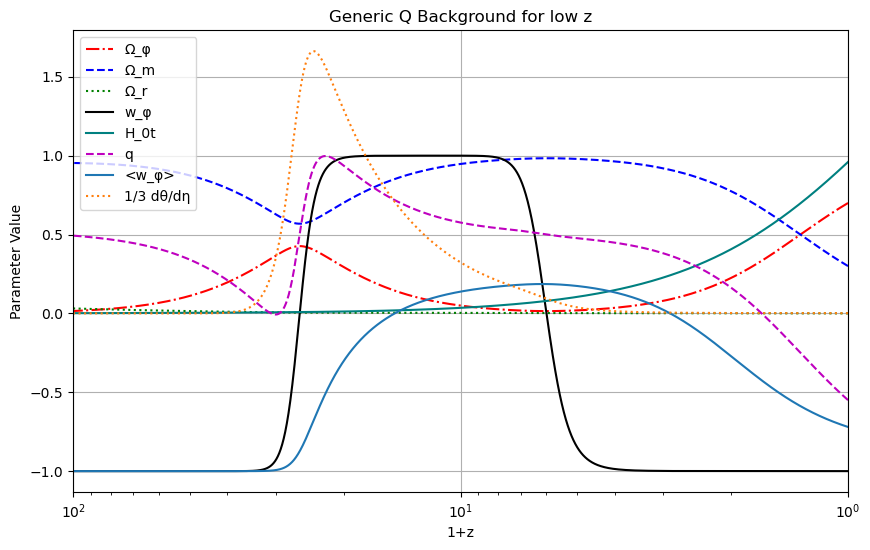

<Figure size 300x500 with 0 Axes>

la: 299.61274480333896


In [18]:
generic_Q_w = lambda z: calculate_w_phi(z, zmin=5, zmax=25, wmax=1)

eta_0 = 0
eta_total = 6
eta_span = [0, -eta_total]
eta_eval = np.linspace(0, -eta_total, 100000)
generic_data = solve_single_case(generic_Q_w, graph = True)
plot_history(generic_data, xlim = 100)

In [19]:
# Define ΛCDM (constant w = -1)
w_phi_LCDM = lambda z: -1.0

# Test parameters (Planck-ish)
Omega_m0_test = 0.315
Omega_b0_test = 0.049
H0_test = 67.4
Omega_phi0_test = 1 - Omega_m0_test - Omega_r0
ICs_test = [3*Omega_phi0_test, 1.0, 1.0, 0.96, 0]

print("="*70)
print("TESTING ΛCDM (w = -1 constant)")
print("="*70)
print(f"Omega_m0: {Omega_m0_test}")
print(f"Omega_phi0: {Omega_phi0_test}")
print(f"H0: {H0_test}")
print()

# Run single case
test_result = solve_single_case(
    w_phi_LCDM, 
    omega_m0=Omega_m0_test, 
    omega_b0=Omega_b0_test, 
    H0=H0_test, 
    initial_state=ICs_test, 
    graph=False
)

wavg, theta, delta_theta = test_result

print("RESULTS:")
print(f"  <w_phi>: {wavg:.6f} (expect: -1.000)")
print(f"  theta: {theta:.6e} rad = {np.degrees(theta):.4f} deg")
print(f"  Expected: 0.0104109 rad = 0.596 deg")
print(f"  delta_theta: {delta_theta*100:.2f}%")
print(f"  Expected: ~0% (should be very small!)")
print()

if abs(delta_theta) < 0.05:  # Less than 5%
    print("✓ LOOKS GOOD! Your code is working correctly.")
else:
    print(f"✗ WARNING: delta_theta = {delta_theta*100:.1f}% is too large!")
    print("   Need to debug further.")

print("="*70)

TESTING ΛCDM (w = -1 constant)
Omega_m0: 0.315
Omega_phi0: 0.6849011
H0: 67.4

Eta 0 calculation: 3.2443070090557846
Eta dec calculation: 0.0626690919324255
Eta dec theoretical: 0.063
rs calculation: 0.03187291441221918
  Expected r_s ≈ 0.033
RESULTS:
  <w_phi>: -1.000000 (expect: -1.000)
  theta: 1.001777e-02 rad = 0.5740 deg
  Expected: 0.0104109 rad = 0.596 deg
  delta_theta: 3.78%
  Expected: ~0% (should be very small!)

✓ LOOKS GOOD! Your code is working correctly.


In [ ]:
start_time = time.time()
num_iters = 20

eta_0 = 0
eta_total = 6
eta_span = [0, -eta_total]
eta_eval = np.linspace(0, -eta_total, 5000)

number_of_widths = num_iters
width_max = 0.9
width_min = 0.1

H0s = np.linspace(60, 75, num_iters)
square_wave_widths = np.linspace(width_min, width_max, number_of_widths)
z_maxes = np.linspace(5, 1000, num_iters)
maxws = np.linspace(-2, -0.5, num_iters)

start_time = time.time()
results = Parallel(n_jobs=-1, verbose=1)(  # n_jobs=-1 uses all cores
    delayed(case_wrapper)(H0, sww, zMax, maxw)
    for H0 in H0s
    for sww in square_wave_widths
    for zMax in z_maxes
    for maxw in maxws
    );

# Unpack results
wavgs, thetas, delta_thetas = zip(*results)

print("Done")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 656 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 1656 tasks      | elapsed:   12.8s


In [21]:
# Build the H0 list t o match
H0_list = []
for H0 in H0s:
    for sww in square_wave_widths:
        for zMax in z_maxes:
            for maxw in maxws:
                H0_list.append(H0)

# Convert to arrays and filter out NaNs/Infs
H0_array = np.array(H0_list)
wavg_array = np.array(wavgs)
delta_theta_array = np.array(delta_thetas) * 100  # Convert to %

# Filter valid results
"""
valid_mask = np.isfinite(wavg_array) & np.isfinite(delta_theta_array)
H0_valid = H0_array[valid_mask] / 100  # Convert to h
wavg_valid = wavg_array[valid_mask]
delta_theta_valid = delta_theta_array[valid_mask]
"""
# Filter valid results AND suppress points with |Δθ| > 2%
valid_mask = (np.isfinite(wavg_array) & 
              np.isfinite(delta_theta_array) & 
              (np.abs(delta_theta_array) <= 2))  # ← NEW: Keep only |Δθ| ≤ 2%

H0_valid = H0_array[valid_mask] / 100  # Convert to h
wavg_valid = wavg_array[valid_mask]
delta_theta_valid = delta_theta_array[valid_mask]

print(f"Valid results: {valid_mask.sum()} out of {len(valid_mask)}")
print(f"<w> range: [{wavg_valid.min():.3f}, {wavg_valid.max():.3f}]")
print(f"Δθ range: [{delta_theta_valid.min():.1f}%, {delta_theta_valid.max():.1f}%]")
print(f"Number with <w> < -1: {(wavg_valid < -1).sum()}")
print(f"Done! Total time: {(time.time() - start_time)/60:.1f} minutes")

Valid results: 3 out of 625
<w> range: [-1.471, -1.014]
Δθ range: [0.9%, 1.9%]
Number with <w> < -1: 3
Done! Total time: 0.1 minutes


In [22]:
from scipy.interpolate import griddata
 
# Grid for plotting
h_grid = np.linspace(0.6, 0.78, 100)
wavg_grid = np.linspace(wavg_valid.min(), wavg_valid.max(), 100)
h_mesh, wavg_mesh = np.meshgrid(h_grid, wavg_grid)

# Interpolate
delta_theta_grid = griddata(
    (H0_valid, wavg_valid), 
    delta_theta_valid,
    (h_mesh, wavg_mesh),
    method='cubic'
)

# CLIP to actual data range!
delta_theta_grid = np.clip(delta_theta_grid, 
                            delta_theta_valid.min(), 
                            delta_theta_valid.max())
# Plot
fig, ax = plt.subplots(figsize=(8, 6))
contour = ax.contourf(h_mesh, wavg_mesh, np.abs(delta_theta_grid), 
                      levels=100, cmap='viridis')
plt.colorbar(contour, label=r'$\Delta\theta_s$ (%)')

ax.axvline(x=0.674, color='black', linestyle='-', linewidth=2, label='Planck')
ax.axvline(x=0.73, color='blue', linestyle='-', linewidth=2, label='SN')

ax.set_xlabel(r'$H_0 / 100$ km/s/Mpc')
ax.set_ylabel(r'$\langle w_\phi \rangle$')
ax.legend()
plt.tight_layout()
plt.show()

QhullError: QH6013 qhull input error: input is less than 3-dimensional since all points have the same x coordinate 0.75

While executing:  | qhull d Q12 Qt Qz Qc Qbb
Options selected for Qhull 2019.1.r 2019/06/21:
  run-id 227874546  delaunay  Q12-allow-wide  Qtriangulate  Qz-infinity-point
  Qcoplanar-keep  Qbbound-last  _pre-merge  _zero-centrum  Qinterior-keep
  Pgood  _max-width 0.46  Error-roundoff 2e-15  _one-merge 1.4e-14
  Visible-distance 4.1e-15  U-max-coplanar 4.1e-15  Width-outside 8.2e-15
  _wide-facet 2.4e-14  _maxoutside 1.6e-14
